In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [42]:


import numpy as np          
import pandas as pd        
import matplotlib.pyplot as plt  
import matplotlib.ticker as mticker  
import seaborn as sns     
import warnings
warnings.filterwarnings('ignore')   


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')


TESLA_RED   = '#E31937'
TESLA_GRAY  = '#5C5C5C'
ACCENT_BLUE = '#2196F3'

print('All libraries loaded successfully')

All libraries loaded successfully


In [43]:


df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print('Shape of dataset:', df.shape)
print('Years covered:', df['Year'].min(), 'to', df['Year'].max())
print('Regions:', df['Region'].unique())
print('Models:', df['Model'].unique())

df.head(8)


Shape of dataset: (2640, 12)
Years covered: 2015 to 2025
Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216


In [44]:


print('Column Info:')
print(df.info())

print('\nMissing Values in each column:')
print(df.isnull().sum())

print('\nBasic Statistics:')
df.describe().round(2)


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values in each column:
Year                    0
Month                   0
Region       

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


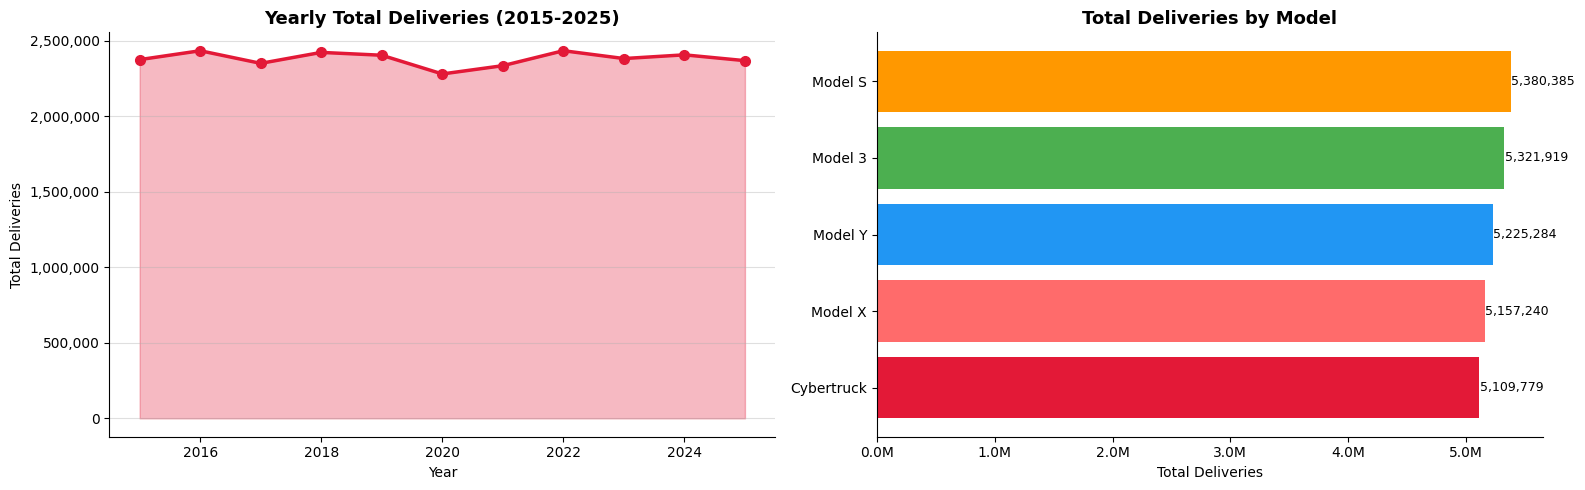

In [45]:


yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


axes[0].fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.3, color=TESLA_RED)
axes[0].plot(yearly['Year'], yearly['Estimated_Deliveries'], color=TESLA_RED, linewidth=2.5, marker='o', markersize=7)
axes[0].set_title('Yearly Total Deliveries (2015-2025)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Deliveries')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(axis='y', alpha=0.4)


model_totals = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True)
bars = axes[1].barh(model_totals.index, model_totals.values,
                    color=[TESLA_RED, '#FF6B6B', ACCENT_BLUE, '#4CAF50', '#FF9800'])
axes[1].set_title('Total Deliveries by Model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Deliveries')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, val in zip(bars, model_totals.values):
    axes[1].text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


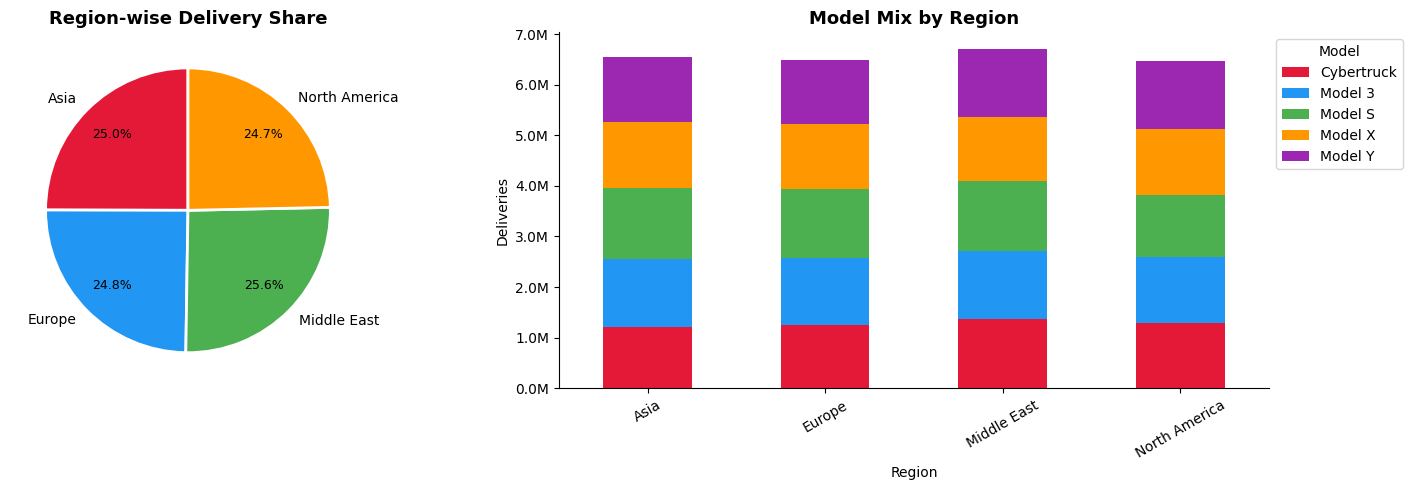

In [46]:


fig, axes = plt.subplots(1, 2, figsize=(16, 5))


region_totals = df.groupby('Region')['Estimated_Deliveries'].sum()
colors_pie = [TESLA_RED, ACCENT_BLUE, '#4CAF50', '#FF9800', '#9C27B0']
wedges, texts, autotexts = axes[0].pie(
    region_totals.values, labels=region_totals.index,
    autopct='%1.1f%%', colors=colors_pie,
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Region-wise Delivery Share', fontsize=13, fontweight='bold')


region_model = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].sum().unstack(fill_value=0)
region_model.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[TESLA_RED, ACCENT_BLUE, '#4CAF50', '#FF9800', '#9C27B0'])
axes[1].set_title('Model Mix by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Deliveries')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].legend(title='Model', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


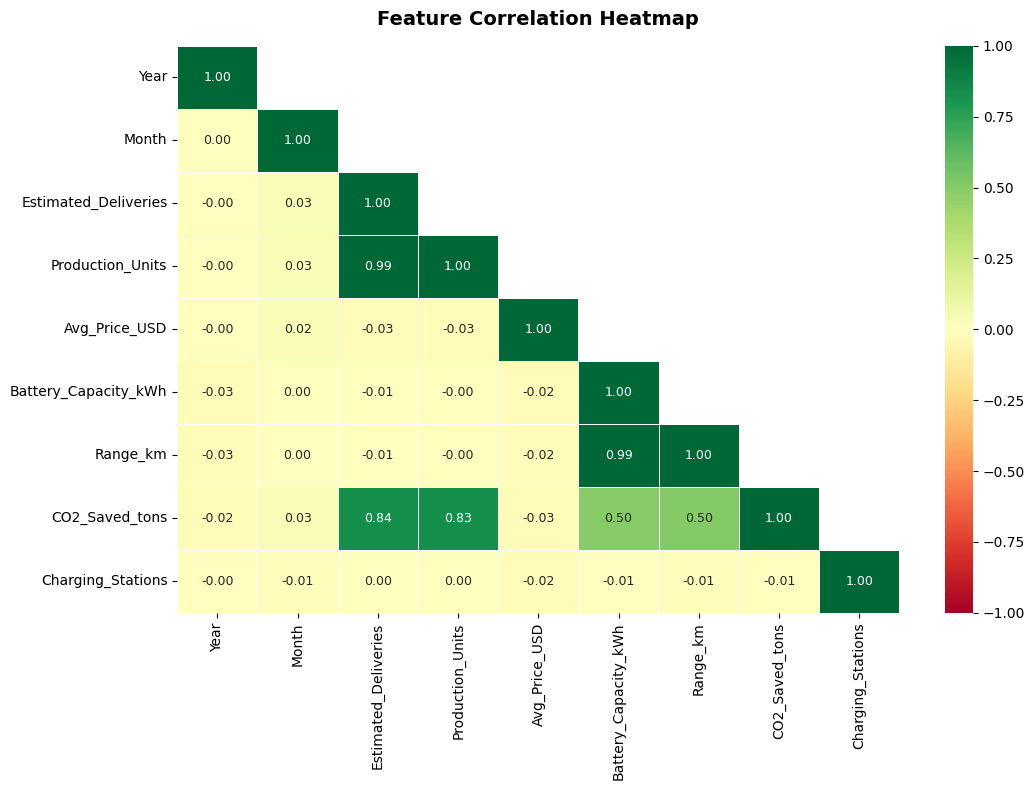

Correlation with Estimated_Deliveries:
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Avg_Price_USD          -0.027546
Battery_Capacity_kWh   -0.007765
Range_km               -0.006606
Year                   -0.002863
Charging_Stations       0.000753
Name: Estimated_Deliveries, dtype: float64


In [47]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values(key=abs, ascending=False)
print('Correlation with Estimated_Deliveries:')
print(target_corr)

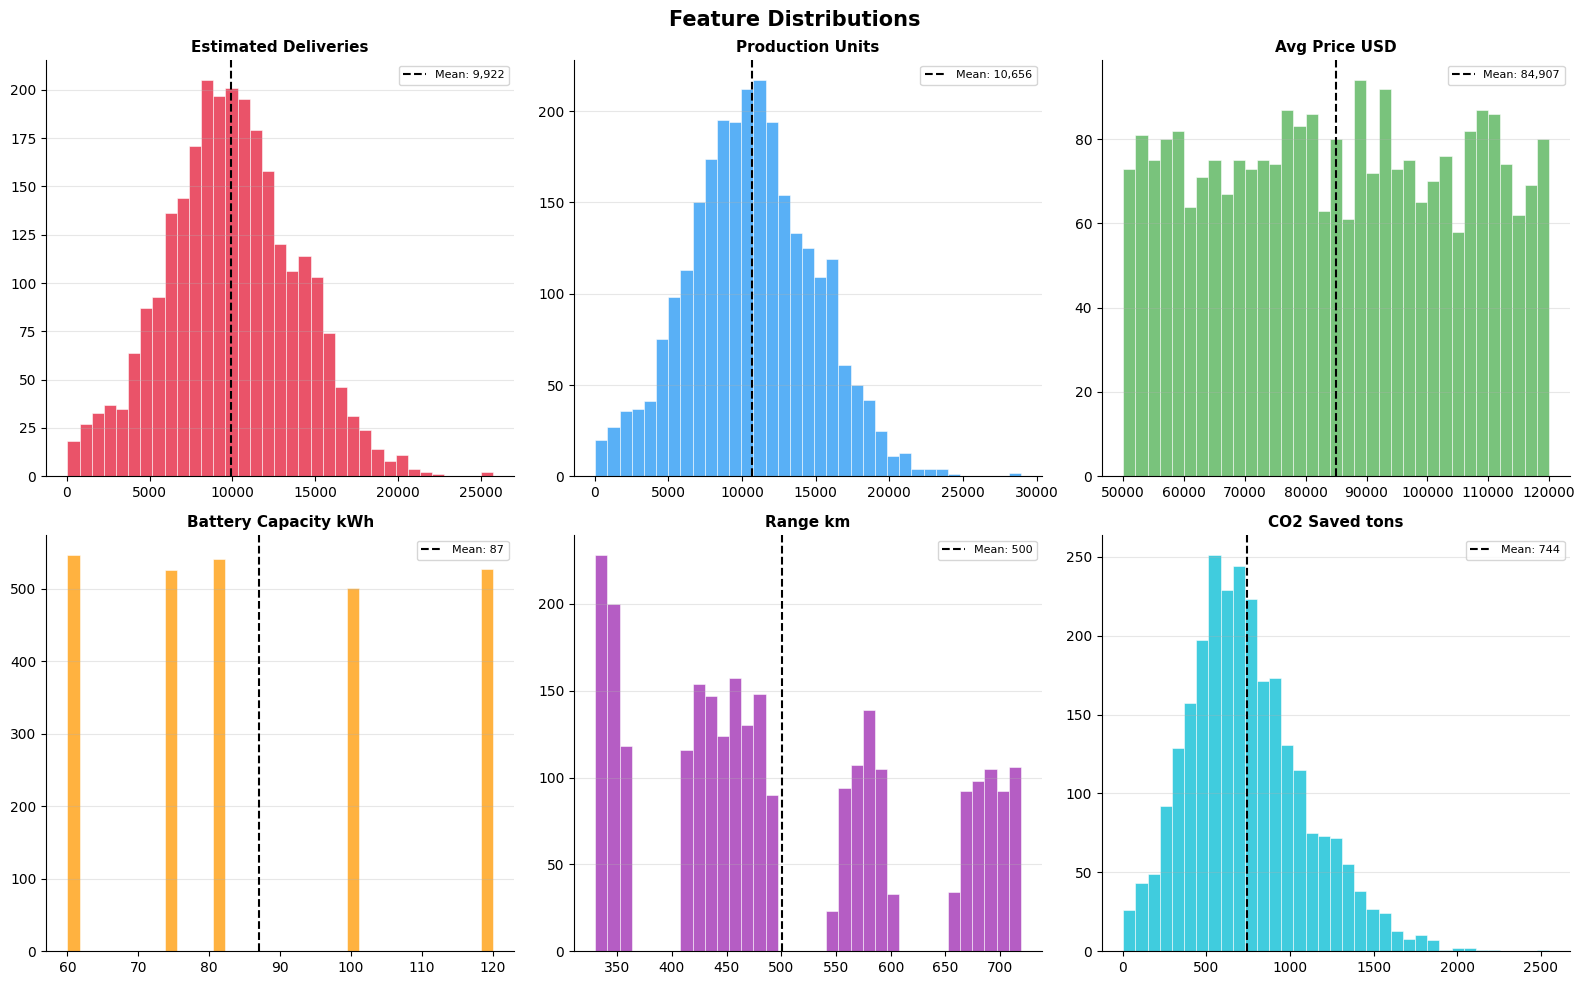

In [48]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions', fontsize=15, fontweight='bold')

plot_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
             'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons']
colors_dist = [TESLA_RED, ACCENT_BLUE, '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

for ax, col, color in zip(axes.flatten(), plot_cols, colors_dist):
    ax.hist(df[col], bins=35, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():,.0f}')
    ax.set_title(col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [49]:


df_ml = df.copy()


le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df_ml['Region_Enc']      = le_region.fit_transform(df_ml['Region'])
df_ml['Model_Enc']       = le_model.fit_transform(df_ml['Model'])
df_ml['Source_Type_Enc'] = le_source.fit_transform(df_ml['Source_Type'])

df_ml['Price_per_km'] = df_ml['Avg_Price_USD'] / (df_ml['Range_km'] + 1)

df_ml['Month_sin'] = np.sin(2 * np.pi * df_ml['Month'] / 12)
df_ml['Month_cos'] = np.cos(2 * np.pi * df_ml['Month'] / 12)

print('Feature engineering done!')
print('Total columns now:', df_ml.shape[1])
df_ml.head(3)

Feature engineering done!
Total columns now: 18


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_Enc,Model_Enc,Source_Type_Enc,Price_per_km,Month_sin,Month_cos
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,1,2,1,131.736553,0.500000,-0.866025
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0,3,2,141.698519,0.866025,0.500000
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,3,3,1,245.087983,0.500000,0.866025


In [50]:

FEATURE_COLS = [
    'Year', 'Month_sin', 'Month_cos',
    'Region_Enc', 'Model_Enc', 'Source_Type_Enc',
    'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km',
    'CO2_Saved_tons', 'Charging_Stations',
    'Price_per_km'
]


TARGET_COL = 'Estimated_Deliveries'

X = df_ml[FEATURE_COLS].values
y = df_ml[TARGET_COL].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Features selected:', len(FEATURE_COLS))
print('Training samples :', X_train_s.shape[0])
print('Testing samples  :', X_test_s.shape[0])
print('scaling done')

Features selected: 13
Training samples : 2112
Testing samples  : 528
scaling done


In [51]:


lr = LinearRegression()
lr.fit(X_train_s, y_train)

y_pred_train_lr = lr.predict(X_train_s)
y_pred_test_lr  = lr.predict(X_test_s)

r2_train_lr   = r2_score(y_train, y_pred_train_lr)
r2_test_lr    = r2_score(y_test,  y_pred_test_lr)
rmse_test_lr  = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))
mae_test_lr   = mean_absolute_error(y_test, y_pred_test_lr)

print('Linear Regression Results')
print(f'  Train R2   : {r2_train_lr:.4f}')
print(f'  Test  R2   : {r2_test_lr:.4f}')
print(f'  Test  RMSE : {rmse_test_lr:,.2f}')
print(f'  Test  MAE  : {mae_test_lr:,.2f}')


gap = r2_train_lr - r2_test_lr
print(f'\n  Overfit Gap: {gap:.4f}')
if gap > 0.05:
    print('  Overfitting detected! Will fix with regularization.')
else:
    print('  Model looks fine')

Linear Regression Results
  Train R2   : 0.9904
  Test  R2   : 0.9901
  Test  RMSE : 383.37
  Test  MAE  : 309.81

  Overfit Gap: 0.0003
  Model looks fine


In [52]:


alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
ridge_scores = []

for a in alphas:
    ridge = Ridge(alpha=a)
    cv_r2 = cross_val_score(ridge, X_train_s, y_train, cv=5, scoring='r2').mean()
    ridge_scores.append(cv_r2)

best_alpha_ridge = alphas[np.argmax(ridge_scores)]
print('Best Alpha for Ridge:', best_alpha_ridge)

ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_s, y_train)

y_pred_train_ridge = ridge_best.predict(X_train_s)
y_pred_test_ridge  = ridge_best.predict(X_test_s)

r2_train_ridge  = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge   = r2_score(y_test,  y_pred_test_ridge)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
mae_test_ridge  = mean_absolute_error(y_test, y_pred_test_ridge)

print('\nRidge Regression Results:')
print(f'  Train R2   : {r2_train_ridge:.4f}')
print(f'  Test  R2   : {r2_test_ridge:.4f}')
print(f'  Test  RMSE : {rmse_test_ridge:,.2f}')
print(f'  Test  MAE  : {mae_test_ridge:,.2f}')
print(f'  Overfit Gap: {r2_train_ridge - r2_test_ridge:.4f}')

Best Alpha for Ridge: 0.1

Ridge Regression Results:
  Train R2   : 0.9904
  Test  R2   : 0.9901
  Test  RMSE : 383.37
  Test  MAE  : 309.79
  Overfit Gap: 0.0003


In [53]:



alphas_lasso = [0.001, 0.01, 0.1, 1, 10, 50, 100]
lasso_scores = []

for a in alphas_lasso:
    lasso = Lasso(alpha=a, max_iter=10000)
    cv_r2 = cross_val_score(lasso, X_train_s, y_train, cv=5, scoring='r2').mean()
    lasso_scores.append(cv_r2)

best_alpha_lasso = alphas_lasso[np.argmax(lasso_scores)]
print('Best Alpha for Lasso:', best_alpha_lasso)


lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train_s, y_train)

y_pred_train_lasso = lasso_best.predict(X_train_s)
y_pred_test_lasso  = lasso_best.predict(X_test_s)

r2_train_lasso  = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso   = r2_score(y_test,  y_pred_test_lasso)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))
mae_test_lasso  = mean_absolute_error(y_test, y_pred_test_lasso)


zero_features = np.sum(lasso_best.coef_ == 0)

print('\nLasso Regression Results:')
print(f'  Train R2          : {r2_train_lasso:.4f}')
print(f'  Test  R2          : {r2_test_lasso:.4f}')
print(f'  Test  RMSE        : {rmse_test_lasso:,.2f}')
print(f'  Test  MAE         : {mae_test_lasso:,.2f}')
print(f'  Overfit Gap       : {r2_train_lasso - r2_test_lasso:.4f}')
print(f'  Features removed  : {zero_features} out of {len(FEATURE_COLS)}')

Best Alpha for Lasso: 1

Lasso Regression Results:
  Train R2          : 0.9904
  Test  R2          : 0.9902
  Test  RMSE        : 383.00
  Test  MAE         : 309.82
  Overfit Gap       : 0.0003
  Features removed  : 2 out of 13


In [54]:



en_scores = []
params_en = []

for a in [0.001, 0.01, 0.1, 1, 10]:
    for l1 in [0.1, 0.3, 0.5, 0.7, 0.9]:
        en = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
        cv_r2 = cross_val_score(en, X_train_s, y_train, cv=5, scoring='r2').mean()
        en_scores.append(cv_r2)
        params_en.append((a, l1))

best_params_en = params_en[np.argmax(en_scores)]
best_alpha_en, best_l1_en = best_params_en
print(f'Best ElasticNet params: alpha={best_alpha_en}, l1_ratio={best_l1_en}')


en_best = ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_en, max_iter=10000)
en_best.fit(X_train_s, y_train)

y_pred_train_en = en_best.predict(X_train_s)
y_pred_test_en  = en_best.predict(X_test_s)

r2_train_en  = r2_score(y_train, y_pred_train_en)
r2_test_en   = r2_score(y_test,  y_pred_test_en)
rmse_test_en = np.sqrt(mean_squared_error(y_test, y_pred_test_en))
mae_test_en  = mean_absolute_error(y_test, y_pred_test_en)

print('\nElasticNet Results:')
print(f'  Train R2   : {r2_train_en:.4f}')
print(f'  Test  R2   : {r2_test_en:.4f}')
print(f'  Test  RMSE : {rmse_test_en:,.2f}')
print(f'  Test  MAE  : {mae_test_en:,.2f}')
print(f'  Overfit Gap: {r2_train_en - r2_test_en:.4f}')



Best ElasticNet params: alpha=0.001, l1_ratio=0.9

ElasticNet Results:
  Train R2   : 0.9904
  Test  R2   : 0.9901
  Test  RMSE : 383.37
  Test  MAE  : 309.76
  Overfit Gap: 0.0003


In [55]:


results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],
    'Train R2':  [r2_train_lr,   r2_train_ridge,   r2_train_lasso,   r2_train_en],
    'Test R2':   [r2_test_lr,    r2_test_ridge,    r2_test_lasso,    r2_test_en],
    'Test RMSE': [rmse_test_lr,  rmse_test_ridge,  rmse_test_lasso,  rmse_test_en],
    'Test MAE':  [mae_test_lr,   mae_test_ridge,   mae_test_lasso,   mae_test_en],
    'Overfit Gap': [
        r2_train_lr - r2_test_lr,
        r2_train_ridge - r2_test_ridge,
        r2_train_lasso - r2_test_lasso,
        r2_train_en - r2_test_en
    ]
})


results = results.round(4).set_index('Model')


best_model_idx = results['Test R2'].idxmax()

print('Model Comparison Table:')
print(results)
print(f'\nBEST MODEL IS: {best_model_idx}')


Model Comparison Table:
                   Train R2  Test R2  Test RMSE  Test MAE  Overfit Gap
Model                                                                 
Linear Regression    0.9904   0.9901   383.3685  309.8088       0.0003
Ridge                0.9904   0.9901   383.3708  309.7862       0.0003
Lasso                0.9904   0.9902   382.9974  309.8166       0.0003
ElasticNet           0.9904   0.9901   383.3729  309.7610       0.0003

BEST MODEL IS: Lasso


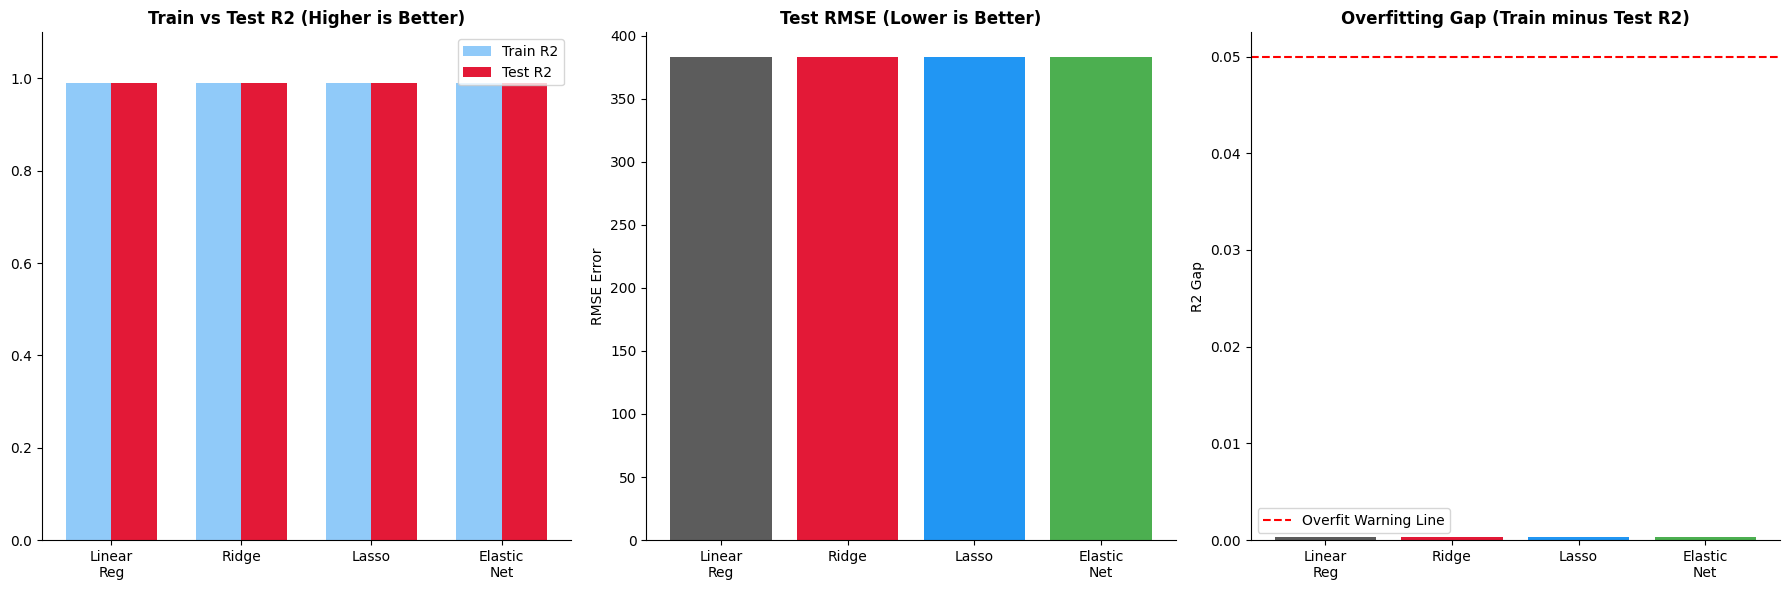

In [56]:


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = ['Linear\nReg', 'Ridge', 'Lasso', 'Elastic\nNet']
bar_colors = [TESLA_GRAY, TESLA_RED, ACCENT_BLUE, '#4CAF50']

# 1. R2 Score Comparison
x = np.arange(4)
w = 0.35
train_r2s = [r2_train_lr, r2_train_ridge, r2_train_lasso, r2_train_en]
test_r2s  = [r2_test_lr,  r2_test_ridge,  r2_test_lasso,  r2_test_en]

b1 = axes[0].bar(x - w/2, train_r2s, w, label='Train R2', color='#90CAF9')
b2 = axes[0].bar(x + w/2, test_r2s,  w, label='Test R2',  color=TESLA_RED)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Train vs Test R2 (Higher is Better)', fontweight='bold')
axes[0].legend()

# 2. RMSE Comparison
rmse_vals = [rmse_test_lr, rmse_test_ridge, rmse_test_lasso, rmse_test_en]
axes[1].bar(model_names, rmse_vals, color=bar_colors)
axes[1].set_title('Test RMSE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('RMSE Error')

# 3. Overfitting Gap Comparison
gaps = [r2_train_lr - r2_test_lr, r2_train_ridge - r2_test_ridge,
        r2_train_lasso - r2_test_lasso, r2_train_en - r2_test_en]
axes[2].bar(model_names, gaps, color=bar_colors)
axes[2].axhline(0.05, color='red', linestyle='--', label='Overfit Warning Line')
axes[2].set_title('Overfitting Gap (Train minus Test R2)', fontweight='bold')
axes[2].set_ylabel('R2 Gap')
axes[2].legend()

plt.tight_layout()
plt.show()


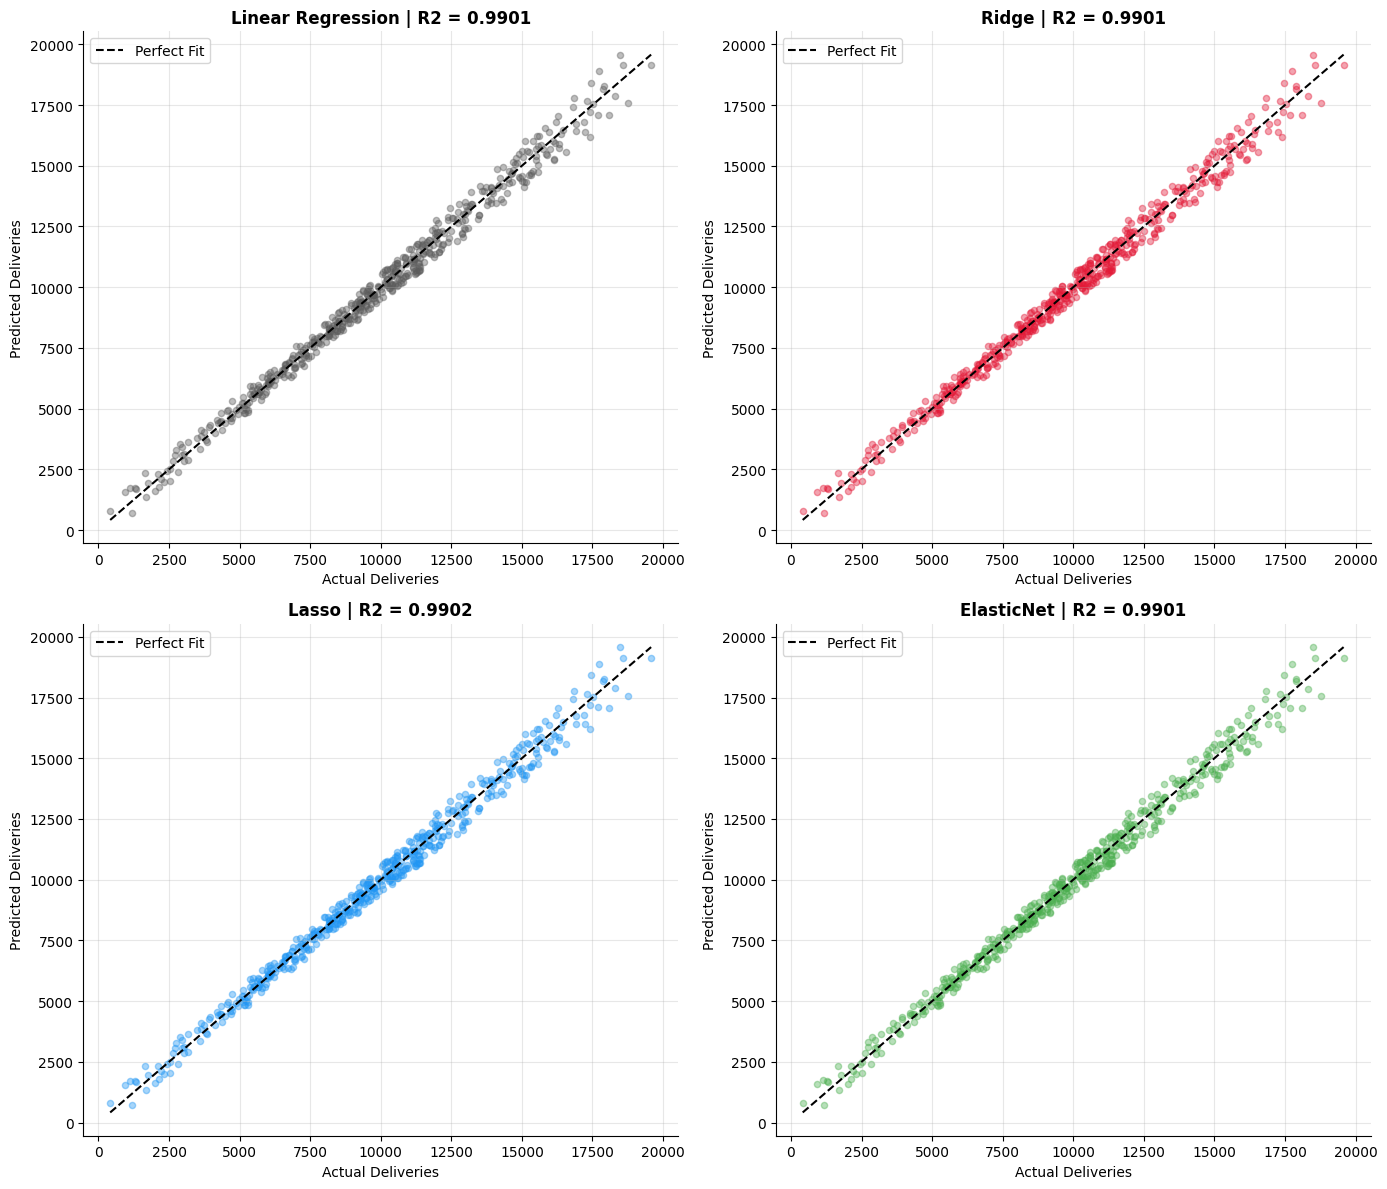

In [57]:


best_preds = {
    'Linear Regression': y_pred_test_lr,
    'Ridge': y_pred_test_ridge,
    'Lasso': y_pred_test_lasso,
    'ElasticNet': y_pred_test_en
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_ap = [TESLA_GRAY, TESLA_RED, ACCENT_BLUE, '#4CAF50']

for ax, (name, preds), color in zip(axes.flatten(), best_preds.items(), colors_ap):
    r2 = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.4, s=20, color=color)
    
  
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit')
    
    ax.set_xlabel('Actual Deliveries')
    ax.set_ylabel('Predicted Deliveries')
    ax.set_title(f'{name} | R2 = {r2:.4f}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

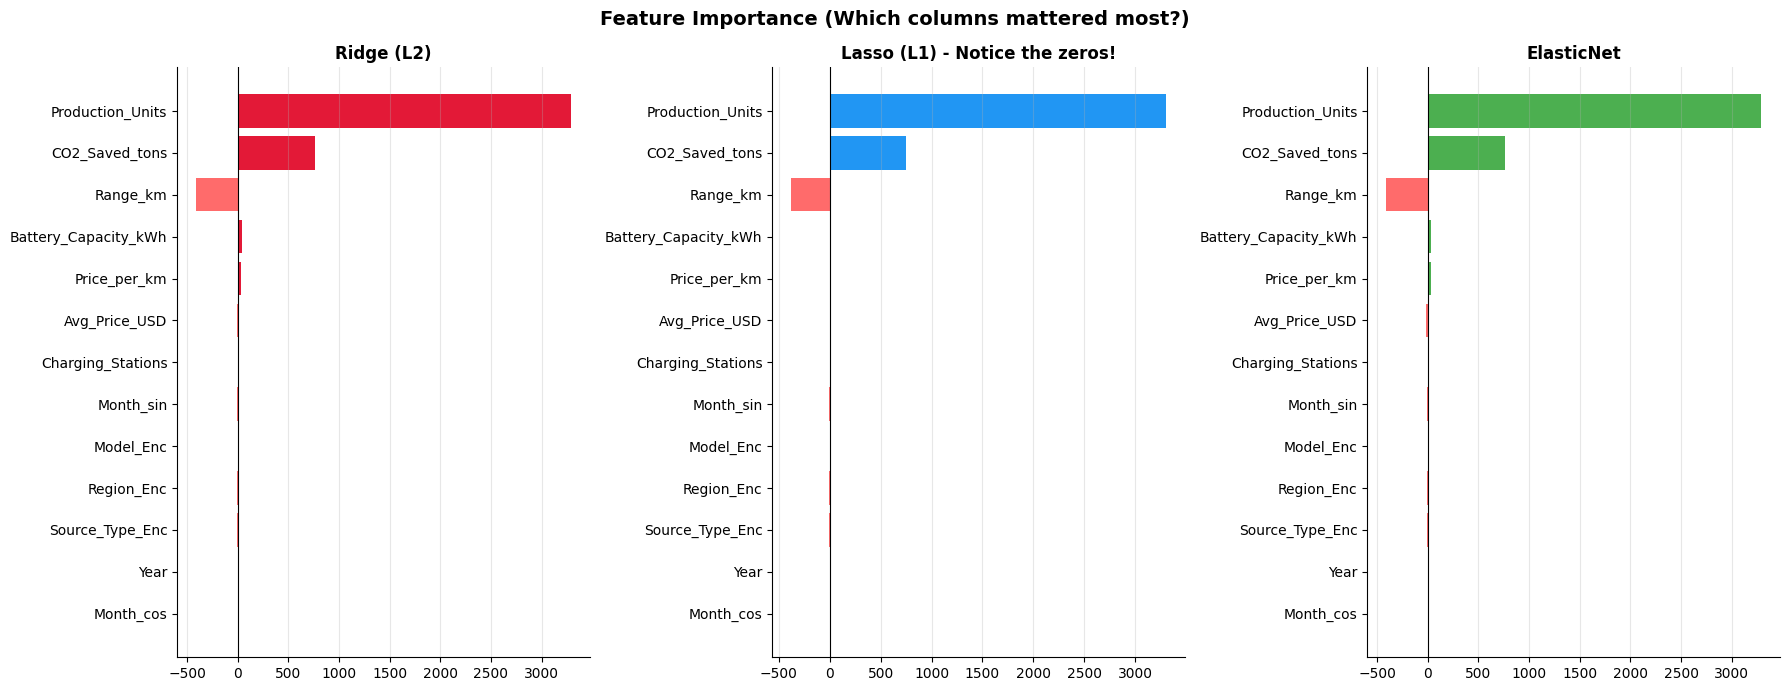

In [58]:

coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Ridge_Coef': ridge_best.coef_,
    'Lasso_Coef': lasso_best.coef_,
    'EN_Coef': en_best.coef_
}).set_index('Feature')


coef_df['Abs_Ridge'] = coef_df['Ridge_Coef'].abs()
coef_df = coef_df.sort_values('Abs_Ridge', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Feature Importance (Which columns mattered most?)', fontsize=14, fontweight='bold')

titles = ['Ridge (L2)', 'Lasso (L1) - Notice the zeros!', 'ElasticNet']
cols = ['Ridge_Coef', 'Lasso_Coef', 'EN_Coef']
colors = [TESLA_RED, ACCENT_BLUE, '#4CAF50']

for ax, col, color, title in zip(axes, cols, colors, titles):
   
    bar_colors = [color if v >= 0 else '#FF6B6B' for v in coef_df[col]]
    
    ax.barh(coef_df.index, coef_df[col], color=bar_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

 Random Forest - GridSearchCV Tuning Start kar rahe hain...

Fitting 3 folds for each of 18 candidates, totalling 54 fits

 Best Parameters Found: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

 Random Forest (Tuned) Results:
  Train R2   : 0.9973
  Test  R2   : 0.9881
  Test  RMSE : 420.40
  Overfit Gap: 0.0092


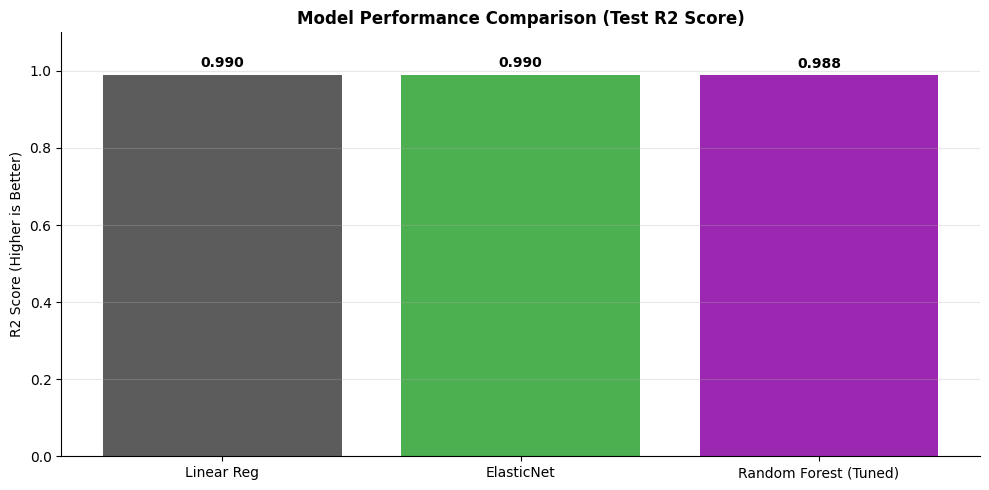

Advanced Tuning Complete


In [59]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print(" Random Forest - GridSearchCV Tuning Start kar rahe hain...\n")


rf_model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           cv=3, scoring='r2', n_jobs=-1, verbose=1)


grid_search.fit(X_train_s, y_train)


best_rf_model = grid_search.best_estimator_
print(f"\n Best Parameters Found: {grid_search.best_params_}")


y_pred_train_rf = best_rf_model.predict(X_train_s)
y_pred_test_rf  = best_rf_model.predict(X_test_s)

r2_train_rf  = r2_score(y_train, y_pred_train_rf)
r2_test_rf   = r2_score(y_test,  y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

print('\n Random Forest (Tuned) Results:')
print(f'  Train R2   : {r2_train_rf:.4f}')
print(f'  Test  R2   : {r2_test_rf:.4f}')
print(f'  Test  RMSE : {rmse_test_rf:,.2f}')
print(f'  Overfit Gap: {r2_train_rf - r2_test_rf:.4f}')


plt.figure(figsize=(10, 5))
models_for_plot = ['Linear Reg', 'ElasticNet', 'Random Forest (Tuned)']
test_r2_scores = [r2_test_lr, r2_test_en, r2_test_rf]

bars = plt.bar(models_for_plot, test_r2_scores, color=[TESLA_GRAY, '#4CAF50', '#9C27B0'])
plt.title('Model Performance Comparison (Test R2 Score)', fontweight='bold')
plt.ylabel('R2 Score (Higher is Better)')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f'{b.get_height():.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Advanced Tuning Complete")

Time Series Data Tayyar Hai!
Pehle 5 rows:
            Estimated_Deliveries
Date                            
2015-01-01                183180
2015-02-01                165053
2015-03-01                184567
2015-04-01                225623
2015-05-01                184264


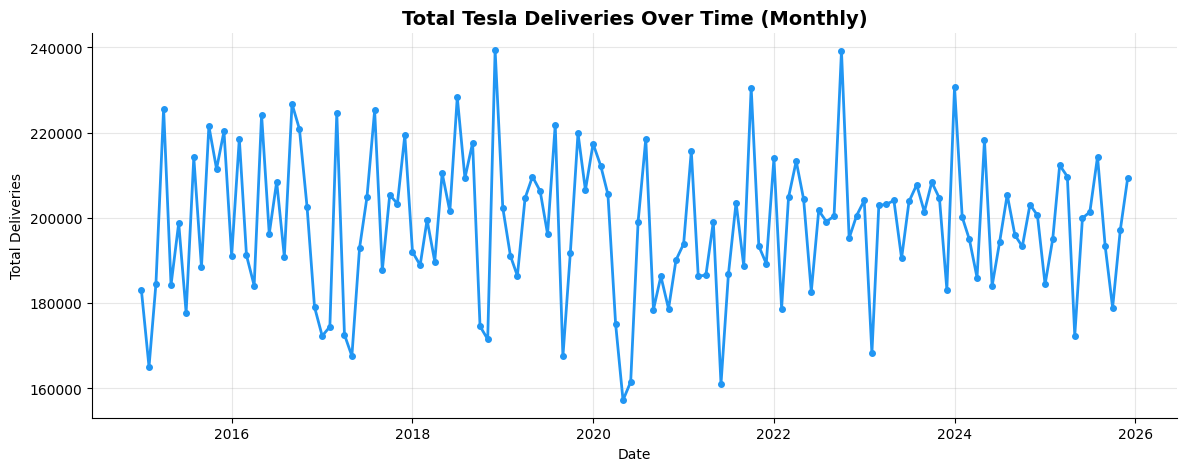

In [60]:

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA


df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')


ts_data = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
ts_data = ts_data.sort_values('Date')
ts_data.set_index('Date', inplace=True)


ts_data.index.freq = 'MS'

print("Time Series Data Tayyar Hai!")
print("Pehle 5 rows:")
print(ts_data.head())

 
plt.figure(figsize=(14, 5))
plt.plot(ts_data.index, ts_data['Estimated_Deliveries'], color=ACCENT_BLUE, linewidth=2, marker='o', markersize=4)
plt.title('Total Tesla Deliveries Over Time (Monthly)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(alpha=0.3)
plt.show()